In [2]:
import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import rasterio as rio
from rasterio.mask import mask
from rasterio.plot import show

In [3]:
os.chdir('..')
os.getcwd()

'/Users/rujalshrestha/Projects/mac-migration/gisc-412/nepal-wildfire'

In [4]:
states = gpd.read_file('output/states.gpkg')
wildfires = gpd.read_file('output/wildfires.gpkg')

In [5]:
wildfires.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,ACQ_DATE,ACQ_TIME,CONFIDENCE,BRIGHT_T31,FRP,datetime,index_right,STATE_CODE,PROVINCE_CODE,PROVINCE_NAME,DISTRICT_CODE,DISTRICT_NAME,STATE_NAME,LAYER_TYPE,SUBDIVISION_CODE,geometry
0,27.5921,87.5385,306.2,2000-11-01,0500,55,292.1,6.2,2000-11-01 05:00:00,28.0,NPL.2.2.4_1,NPL.2_1,East,NPL.2.2_1,Mechi,Taplejung,District,NP.PW.TP,POINT (87.5385 27.5921)
1,29.1006,81.9170,330.6,2000-11-06,0518,87,293.7,43.0,2000-11-06 05:18:00,52.0,NPL.4.2.4_1,NPL.4_1,Mid-Western,NPL.4.2_1,Karnali,Kalikot,District,NP.MP.KK,POINT (81.917 29.1006)
2,30.0881,81.3358,308.7,2000-11-07,0601,58,291.2,21.1,2000-11-07 06:01:00,50.0,NPL.4.2.2_1,NPL.4_1,Mid-Western,NPL.4.2_1,Karnali,Humla,District,NP.MP.HU,POINT (81.3358 30.0881)
3,30.0841,81.3570,306.0,2000-11-07,0601,37,287.4,17.1,2000-11-07 06:01:00,50.0,NPL.4.2.2_1,NPL.4_1,Mid-Western,NPL.4.2_1,Karnali,Humla,District,NP.MP.HU,POINT (81.357 30.0841)
4,30.1060,81.9647,315.0,2000-11-08,0506,64,282.6,41.6,2000-11-08 05:06:00,50.0,NPL.4.2.2_1,NPL.4_1,Mid-Western,NPL.4.2_1,Karnali,Humla,District,NP.MP.HU,POINT (81.9647 30.106)


   DISTRICT_NAME PROVINCE_NAME STATE_NAME
45         Bheri   Mid-Western    Bardiya


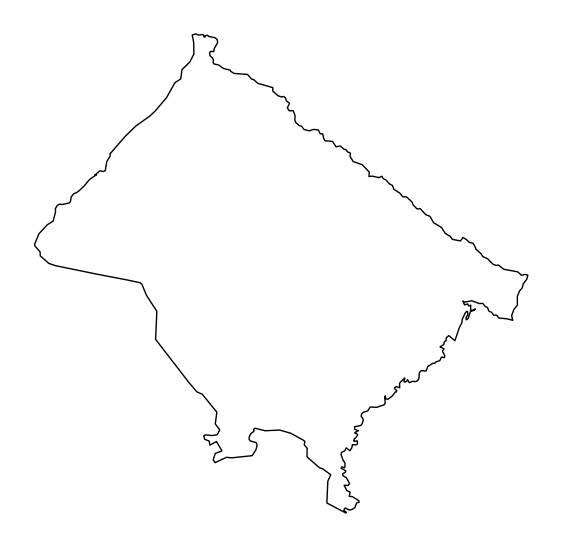

In [6]:
bardiya = states[states['STATE_CODE'] == "NPL.4.1.2_1"]

fig, ax = plt.subplots(figsize=(7, 7))

bardiya.plot(ax = ax, edgecolor='black', facecolor='none')
ax.set_axis_off()

print(bardiya[["DISTRICT_NAME", "PROVINCE_NAME", "STATE_NAME"]])

In [7]:
wildfires.crs == bardiya.crs

True

In [8]:
# level 4 code (state code) for bardiya = NPL.4.1.2_1
fires_bardiya = wildfires[wildfires['STATE_CODE'] == "NPL.4.1.2_1"]

In [9]:
# copernicus dataset covers all the areas of Nepal, which is too large and crashes the kernel when loading
# so we clip and load only for bardiya
with rio.open("data/Topography/copernicus_cop30.tif") as src:
    cop30_bardiya, out_transform = mask(src, bardiya.geometry, crop=True)
    out_meta = src.meta.copy()

out_meta.update({
    "driver": "GTiff",
    "height": cop30_bardiya.shape[1],
    "width": cop30_bardiya.shape[2],
    "transform": out_transform
})

# this will be our bardiya dem dataset for future use
with rio.open("output/Topography/cop30_bardiya.tif", "w", **out_meta) as dest:
    dest.write(cop30_bardiya)

In [ ]:
# calculate aspect and slope using elevation data
dem = cop30_bardiya[0].astype(float)
xres = out_transform.a
yres = -out_transform.e

gy, gx = np.gradient(dem, yres, xres)

# slope using formula
slope = np.degrees(np.arctan(np.sqrt(gx**2 + gy**2)))

# aspect
aspect = np.degrees(np.arctan2(-gx, gy))
aspect = np.where(aspect < 0, 360 + aspect, aspect)

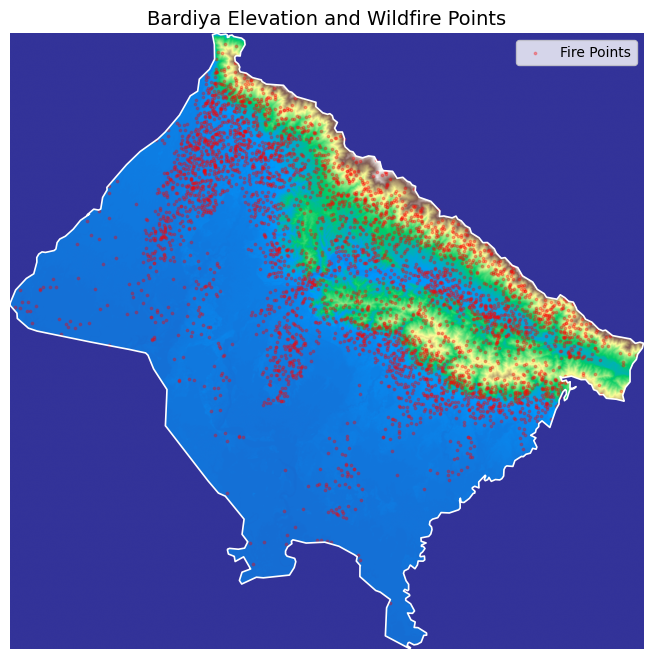

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(12,8))

show(cop30_bardiya, transform=out_transform, cmap='terrain', ax=ax)

bardiya.boundary.plot(ax=ax, color='white', linewidth=1.2)
fires_bardiya.plot(ax=ax, color='red', markersize=3, label='Fire Points', alpha=0.3)

plt.title("Bardiya Elevation and Wildfire Points", fontsize=14)
plt.legend()
ax.set_axis_off()
plt.show()


In [12]:
# add elevation value to each fire point
with rio.open("output/Topography/cop30_bardiya.tif") as src:
    fires_bardiya.loc[:,"elevation"] = [
        x[0] for x in src.sample([
            (pt.x, pt.y) for pt in fires_bardiya.geometry
        ])
    ]
    
fires_bardiya.head()

/Users/rujalshrestha/Projects/mac-migration/gisc-412/gisc-env/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,LATITUDE,LONGITUDE,BRIGHTNESS,ACQ_DATE,ACQ_TIME,CONFIDENCE,BRIGHT_T31,FRP,datetime,index_right,STATE_CODE,PROVINCE_CODE,PROVINCE_NAME,DISTRICT_CODE,DISTRICT_NAME,STATE_NAME,LAYER_TYPE,SUBDIVISION_CODE,geometry,elevation
107,28.3719,81.6756,300.7,2001-01-15,0618,41,288.3,43.4,2001-01-15 06:18:00,45.0,NPL.4.1.2_1,NPL.4_1,Mid-Western,NPL.4.1_1,Bheri,Bardiya,District,NP.MP.BR,POINT (81.6756 28.3719),405.107330
108,28.3621,81.7170,301.4,2001-01-15,0618,46,288.5,47.8,2001-01-15 06:18:00,45.0,NPL.4.1.2_1,NPL.4_1,Mid-Western,NPL.4.1_1,Bheri,Bardiya,District,NP.MP.BR,POINT (81.717 28.3621),419.937744
109,28.3599,81.7107,304.1,2001-01-15,0618,58,288.8,56.6,2001-01-15 06:18:00,45.0,NPL.4.1.2_1,NPL.4_1,Mid-Western,NPL.4.1_1,Bheri,Bardiya,District,NP.MP.BR,POINT (81.7107 28.3599),316.850891
202,28.5021,81.2749,306.8,2001-02-10,0517,62,292.4,8.6,2001-02-10 05:17:00,45.0,NPL.4.1.2_1,NPL.4_1,Mid-Western,NPL.4.1_1,Bheri,Bardiya,District,NP.MP.BR,POINT (81.2749 28.5021),192.348419
203,28.5006,81.2889,305.4,2001-02-10,0517,52,294.1,7.2,2001-02-10 05:17:00,45.0,NPL.4.1.2_1,NPL.4_1,Mid-Western,NPL.4.1_1,Bheri,Bardiya,District,NP.MP.BR,POINT (81.2889 28.5006),175.319122


In [13]:
# elevation statistics (meters)
print(fires_bardiya["elevation"].describe())

count    4260.000000
mean      354.216064
std       212.917068
min       139.346710
25%       204.778778
50%       270.365128
75%       438.229805
max      1490.463501
Name: elevation, dtype: float64


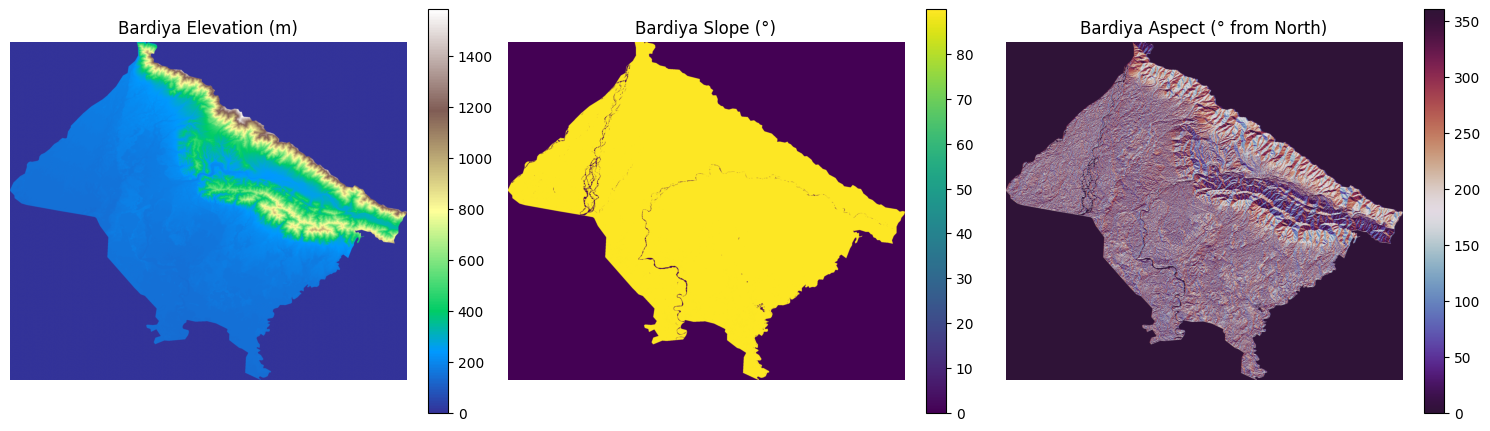

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Elevation using dem 
elev_plot = axes[0].imshow(dem, cmap="terrain")
axes[0].set_title("Bardiya Elevation (m)")
plt.colorbar(elev_plot, ax=axes[0], fraction=0.046)

# Slope
slope_plot = axes[1].imshow(slope, cmap="viridis")
axes[1].set_title("Bardiya Slope (°)")
plt.colorbar(slope_plot, ax=axes[1], fraction=0.046)

# Aspect
aspect_plot = axes[2].imshow(aspect, cmap="twilight_shifted")
axes[2].set_title("Bardiya Aspect (° from North)")
plt.colorbar(aspect_plot, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_axis_off()

plt.tight_layout()
plt.show()

# basic terrain statistics

In [14]:
print(f"Elevation: {np.nanmin(dem):.1f} – {np.nanmax(dem):.1f} m")
print(f"Mean Elevation: {np.nanmean(dem):.2f}")
print(f"Slope: {np.nanmin(slope):.1f} – {np.nanmax(slope):.1f}°")
print(f"Mean Slope: {np.nanmean(slope):.2f}°")

Elevation: 0.0 – 1583.7 m
Mean Elevation: 122.55
Slope: 0.0 – 90.0°
Mean Slope: 38.46°


# More granular analysis into municipality level within Bardiya State

In [15]:
# layer 0 = country
# layer 1 = province
# layer 2 = district
# layer 3 = state
# layer 4 = municipality
states_full = gpd.read_file('data/gadm41_NPL.gpkg', layer='ADM_ADM_4')

In [16]:
states_full.head()

,GID_4,GID_0,COUNTRY,GID_1,NAME_1,GID_2,NAME_2,GID_3,NAME_3,NAME_4,VARNAME_4,TYPE_4,ENGTYPE_4,CC_4,geometry
0,NPL.1.1.1.1_1,NPL,Nepal,NPL.1_1,Central,NPL.1.1_1,Bagmati,NPL.1.1.1_1,Bhaktapur,Bageswari,NA,Village development committee,Village development committee,NA,"MULTIPOLYGON (((85.45114 27.67559, 85.44691 27..."
1,NPL.1.1.1.2_1,NPL,Nepal,NPL.1_1,Central,NPL.1.1_1,Bagmati,NPL.1.1.1_1,Bhaktapur,Balkot,NA,Village development committee,Village development committee,NA,"MULTIPOLYGON (((85.38814 27.67087, 85.38876 27..."
2,NPL.1.1.1.3_1,NPL,Nepal,NPL.1_1,Central,NPL.1.1_1,Bagmati,NPL.1.1.1_1,Bhaktapur,BhaktapurN.P.,NA,Village development committee,Village development committee,NA,"MULTIPOLYGON (((85.44903 27.68218, 85.44691 27..."
3,NPL.1.1.1.4_1,NPL,Nepal,NPL.1_1,Central,NPL.1.1_1,Bagmati,NPL.1.1.1_1,Bhaktapur,Changunarayan,NA,Village development committee,Village development committee,NA,"MULTIPOLYGON (((85.45748 27.72046, 85.45474 27..."
4,NPL.1.1.1.5_1,NPL,Nepal,NPL.1_1,Central,NPL.1.1_1,Bagmati,NPL.1.1.1_1,Bhaktapur,Chhaling,NA,Village development committee,Village development committee,NA,"MULTIPOLYGON (((85.47339 27.70455, 85.47289 27..."


In [17]:
bardiya_municipalities = states_full[states_full['GID_3'] == 'NPL.4.1.2_1'][['NAME_4', 'geometry']].reset_index()

bardiya_municipalities.head()

,index,NAME_4,geometry
0,2569,Badalpur,"MULTIPOLYGON (((81.12878 28.44646, 81.13213 28..."
1,2570,Baganaha,"MULTIPOLYGON (((81.35322 28.41987, 81.34365 28..."
2,2571,Baniyabhar,"MULTIPOLYGON (((81.30164 28.36481, 81.30537 28..."
3,2572,Belawa,"MULTIPOLYGON (((81.59071 28.23619, 81.59232 28..."
4,2573,Bhimapur,"MULTIPOLYGON (((81.15041 28.37132, 81.13278 28..."


<Axes: >

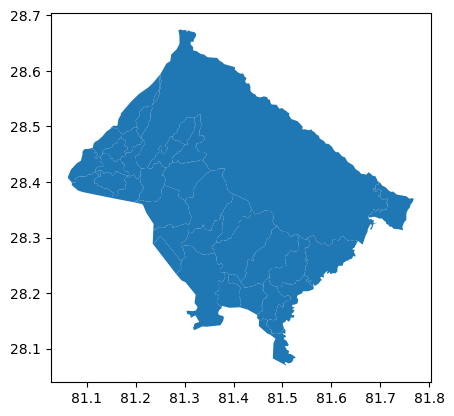

In [18]:
bardiya_municipalities.plot()

In [19]:
# for analysis on which municipality is affected most by wildfire
bardiya_mun_fires = gpd.sjoin(fires_bardiya, bardiya_municipalities, how='inner', predicate='within').drop(columns=[
  'index_right',
  'STATE_CODE',
  'PROVINCE_CODE',
  'PROVINCE_NAME',
  'DISTRICT_CODE',
  'DISTRICT_NAME',
  'SUBDIVISION_CODE',
  'index_right0',
  'index',
  'STATE_NAME',
  'LAYER_TYPE'
]).rename(columns={'NAME_4':'municipality'})

In [20]:
bardiya_mun_fires.to_file("output/bardiya_fire.gpkg", layer="bardiya", driver="GPKG")

In [21]:
fire_counts = bardiya_mun_fires.groupby("municipality").size().reset_index(name="FIRE_COUNT")
fire_counts.sort_values(by='FIRE_COUNT', ascending=False).head()

,municipality,FIRE_COUNT
26,Royal Bardiya Nation,3683
2,Baniyabhar,162
3,Belawa,83
6,Deudakala,51
8,Dhodhari,28


In [22]:
elev_stats = bardiya_mun_fires.groupby("municipality")["elevation"].mean().reset_index(name="mean_elev")

In [23]:
fire_elev = fire_counts.merge(elev_stats, on="municipality", how="left")
fire_elev.sort_values(by='FIRE_COUNT', ascending=False).head()

,municipality,FIRE_COUNT,mean_elev
26,Royal Bardiya Nation,3683,376.552643
2,Baniyabhar,162,180.493546
3,Belawa,83,454.967194
6,Deudakala,51,178.240036
8,Dhodhari,28,171.101120
